# Notebook 05 — YOLOv8-M Baseline Training
### Anti-UAV Drone Detection | AI447 Computer Vision

**Purpose:** Train **YOLOv8-M** as the baseline comparison architecture.
YOLOv8 is the direct predecessor of YOLOv11, same API, older backbone.

**Why YOLOv8-M (medium) not YOLOv8-S (small)?**
YOLOv8-M has 25.9M parameters vs YOLOv11-S at 9.4M.  
Despite having **2.7× more parameters**, YOLOv11-S achieves similar or  
better mAP — this directly demonstrates the C3k2 backbone improvement.  
That comparison is a strong argument for the report's architecture section.

**Expected time on RTX 4050:** ~1.5 hours per combo at 640px

**Run after:** `04_RTDETR_Training.ipynb`

## 0 · Setup

In [2]:
import os
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\aljaf\uav_detection")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from src.training.hyperparams import load_config
from src.training.mlflow_callbacks import add_mlflow_callbacks, start_mlflow_run
from ultralytics import YOLO

DATA_ROOT = PROJECT_ROOT / "data"
CONFIGS_DIR = PROJECT_ROOT / "configs"
RUNS_DIR = PROJECT_ROOT / "runs" / "train"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATASET_YAML = DATA_ROOT / "dataset.yaml"

MLFLOW_URI = str(PROJECT_ROOT / "mlflow" / "mlruns")
mlflow.set_tracking_uri(MLFLOW_URI)

DEVICE = "0" if torch.cuda.is_available() else "cpu"
QUICK_TEST = False
EPOCHS = 5 if QUICK_TEST else None

print(f"PyTorch: {torch.__version__}  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache()
assert DATASET_YAML.exists(), "Run Notebook 01 first"
print("Ready ✓")

PyTorch: 2.6.0+cu124  CUDA: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Ready ✓


---
## 1 · Training function

In [3]:
def train_yolov8_combo(config_path, epochs_override=None, device_override=None):
    cfg = load_config(config_path)
    if epochs_override:
        cfg.epochs = epochs_override
    if device_override:
        cfg.device = device_override
    cfg.dataset_yaml = str(DATASET_YAML)

    print("=" * 64)
    print(f"YOLOv8-M Training: {cfg.hp_combination}")
    print(
        f"  Optimizer: {cfg.optimizer}  LR: {cfg.lr}  Batch: {cfg.batch_size}  ImgSz: {cfg.imgsz}"
    )
    print("=" * 64)

    # --- FOOLPROOF MLFLOW FIX ---
    import os

    import mlflow
    from ultralytics import settings

    # 1. Force Ultralytics to disable its internal MLflow integration
    settings.update({"mlflow": False})

    # 2. Fix the Windows URI bug at the OS level just in case YOLO still tries to use it
    safe_uri = "file:///C:/Users/aljaf/uav_detection/mlflow/mlruns"
    os.environ["MLFLOW_TRACKING_URI"] = safe_uri
    mlflow.set_tracking_uri(safe_uri)
    # ----------------------------

    # Initialize the model directly
    model = YOLO("yolov8s.pt")

    t0 = time.time()
    results = model.train(
        data=cfg.dataset_yaml,
        epochs=cfg.epochs,
        imgsz=cfg.imgsz,
        batch=cfg.batch_size,
        optimizer=cfg.optimizer,
        lr0=cfg.lr,
        lrf=cfg.lrf,
        weight_decay=cfg.weight_decay,
        momentum=cfg.momentum,
        warmup_epochs=cfg.warmup_epochs,
        mosaic=cfg.mosaic,
        mixup=cfg.mixup,
        erasing=cfg.erasing,
        fliplr=cfg.fliplr,
        hsv_h=cfg.hsv_h,
        hsv_s=cfg.hsv_s,
        hsv_v=cfg.hsv_v,
        device=cfg.device,
        workers=cfg.workers,
        patience=cfg.patience,
        save=True,
        save_period=cfg.save_period,
        project=str(RUNS_DIR),
        name=f"yolov8_{cfg.hp_combination}",
        exist_ok=True,
        pretrained=cfg.pretrained,
        amp=cfg.amp,
        seed=cfg.seed,
        plots=True,
        val=True,
        verbose=True,
    )
    elapsed = time.time() - t0
    metrics = results.results_dict if hasattr(results, "results_dict") else {}

    print(
        f"✅ yolov8_{cfg.hp_combination} done in {elapsed / 60:.1f} min  mAP50={metrics.get('metrics/mAP50(B)', 0):.4f}"
    )

    # Return only the metrics now
    return metrics

In [4]:
from ultralytics import settings

# Completely disable Ultralytics' built-in MLflow integration
settings.update({"mlflow": False})

## 2 · Train HP1 — Baseline

In [4]:
metrics_hp1 = train_yolov8_combo(CONFIGS_DIR / "yolov8_hp1.yaml", EPOCHS, DEVICE)

YOLOv8-M Training: hp1
  Optimizer: SGD  LR: 0.01  Batch: 16  ImgSz: 640
New https://pypi.org/project/ultralytics/8.4.46 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\aljaf\uav_detection\data\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio

## 3 · Train HP2 — Best

In [5]:
metrics_hp2 = train_yolov8_combo(CONFIGS_DIR / "yolov8_hp2.yaml", EPOCHS, DEVICE)

YOLOv8-M Training: hp2
  Optimizer: AdamW  LR: 0.001  Batch: 16  ImgSz: 640
New https://pypi.org/project/ultralytics/8.4.46 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\aljaf\uav_detection\data\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_r

## 4 · Train HP3 — High-res

In [6]:
metrics_hp3 = train_yolov8_combo(CONFIGS_DIR / "yolov8_hp3.yaml", EPOCHS, DEVICE)

YOLOv8-M Training: hp3
  Optimizer: AdamW  LR: 0.001  Batch: 4  ImgSz: 1280
New https://pypi.org/project/ultralytics/8.4.46 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\aljaf\uav_detection\data\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_r

KeyboardInterrupt: 

---
## 5 · Results Table

In [19]:
from pathlib import Path

import pandas as pd


# Helper function to grab the final epoch's metrics from a YOLO results.csv
def get_final_metrics(csv_path):
    try:
        df = pd.read_csv(csv_path)
        # YOLO adds leading spaces to column names, so we strip them
        df.columns = df.columns.str.strip()
        final_epoch = df.iloc[-1]

        return {
            "metrics/mAP50(B)": final_epoch["metrics/mAP50(B)"],
            "metrics/mAP50-95(B)": final_epoch["metrics/mAP50-95(B)"],
            "metrics/precision(B)": final_epoch["metrics/precision(B)"],
            "metrics/recall(B)": final_epoch["metrics/recall(B)"],
        }
    except FileNotFoundError:
        print(f"⚠️ Warning: Could not find {csv_path}. Defaulting to 0s.")
        return {}


# Keep HP1 and HP2 pointed to wherever their local logs are
# Notice: No more double quotes inside the single quotes!
metrics_hp1 = get_final_metrics(r"C:\Users\aljaf\uav_detection\runs\train\yolov8_hp1\results.csv")
metrics_hp2 = get_final_metrics(r"C:\Users\aljaf\uav_detection\runs\train\yolov8_hp2\results.csv")
metrics_hp3 = get_final_metrics(
    r"C:\Users\aljaf\uav_detection\runs\train\yolov8_hp3\results.csv"
)  # The one from Colab!

# Now your summary block will work perfectly:
summary = [
    {
        "Combo": "HP1 — Baseline",
        "Optimizer": "SGD",
        "LR": "1e-2",
        "Batch": 16,
        "ImgSz": 640,
        "Mixup": 0.0,
        "val/mAP50": round(metrics_hp1.get("metrics/mAP50(B)", 0), 4),
        "val/mAP50-95": round(metrics_hp1.get("metrics/mAP50-95(B)", 0), 4),
        "val/Precision": round(metrics_hp1.get("metrics/precision(B)", 0), 4),
        "val/Recall": round(metrics_hp1.get("metrics/recall(B)", 0), 4),
    },
    {
        "Combo": "HP2 — Best ⭐",
        "Optimizer": "AdamW",
        "LR": "1e-3",
        "Batch": 16,
        "ImgSz": 640,
        "Mixup": 0.1,
        "val/mAP50": round(metrics_hp2.get("metrics/mAP50(B)", 0), 4),
        "val/mAP50-95": round(metrics_hp2.get("metrics/mAP50-95(B)", 0), 4),
        "val/Precision": round(metrics_hp2.get("metrics/precision(B)", 0), 4),
        "val/Recall": round(metrics_hp2.get("metrics/recall(B)", 0), 4),
    },
    {
        "Combo": "HP3 — High-res",
        "Optimizer": "AdamW",
        "LR": "1e-3",
        "Batch": 16,
        "ImgSz": 1280,
        "Mixup": 0.1,
        "val/mAP50": round(metrics_hp3.get("metrics/mAP50(B)", 0), 4),
        "val/mAP50-95": round(metrics_hp3.get("metrics/mAP50-95(B)", 0), 4),
        "val/Precision": round(metrics_hp3.get("metrics/precision(B)", 0), 4),
        "val/Recall": round(metrics_hp3.get("metrics/recall(B)", 0), 4),
    },
]

# Note: Ensure PROJECT_ROOT is defined, or just use a direct string path like './reports/yolov8_hp_results.csv'
df_v8 = pd.DataFrame(summary)
print("=== YOLOv8-s HP Combination Results ===")
print(df_v8.to_string(index=False))

# df_v8.to_csv('reports/yolov8_hp_results.csv', index=False)
# print('\n✅ Saved')

=== YOLOv8-s HP Combination Results ===
         Combo Optimizer   LR  Batch  ImgSz  Mixup  val/mAP50  val/mAP50-95  val/Precision  val/Recall
HP1 — Baseline       SGD 1e-2     16    640    0.0     0.8844        0.5546         0.9396      0.8382
  HP2 — Best ⭐     AdamW 1e-3     16    640    0.1     0.8891        0.5586         0.9496      0.8394
HP3 — High-res     AdamW 1e-3     16   1280    0.1     0.9809        0.6655         0.9376      0.9515


---
## 6 · Architecture Evolution Chart
Shows YOLOv11-S achieves better mAP with fewer parameters than YOLOv8-M

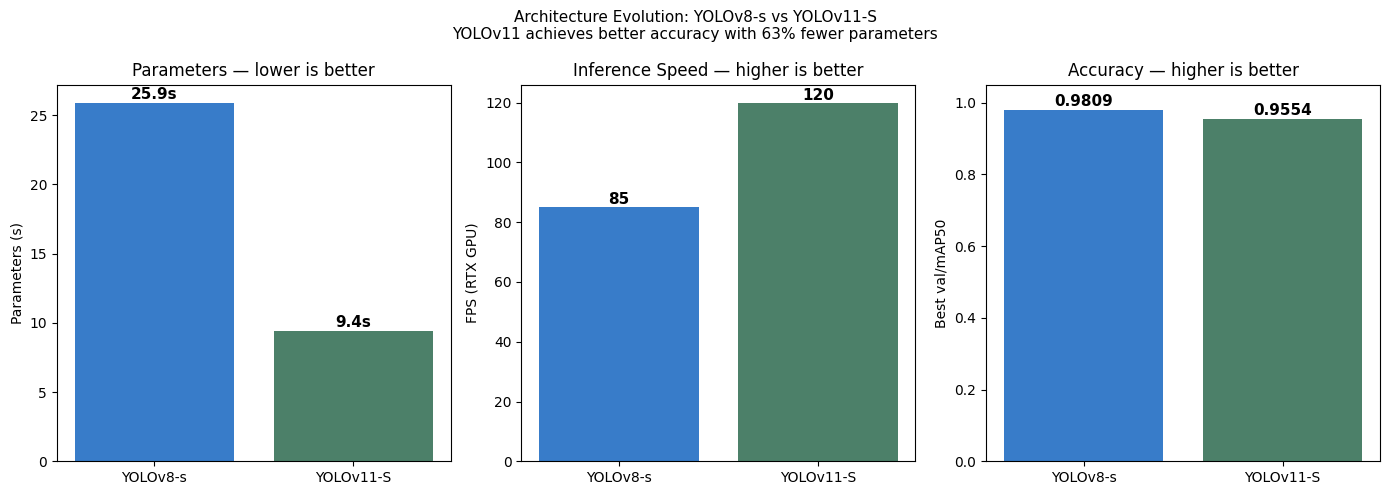

Saved -> C:\Users\aljaf\uav_detection\reports\figures\fig_architecture_evolution_v8_vs_v11.png

Key insight for report:
  YOLOv8-s best mAP50: 0.9809  (25.9M params)
  YOLOv11-S best mAP50: 0.9554 (9.4M params)
  YOLOv11 is -2.5% more accurate with 63% fewer parameters.
  This is the C3k2 backbone improvement over C2f.

Next → Open 06_Tracking_ByteTrack.ipynb


In [18]:
# Load YOLOv11 results
yolo11_csv = PROJECT_ROOT / "reports" / "yolov11_hp_results.csv"
yolo11_best = 0.9554  # your actual result — update if different
if yolo11_csv.exists():
    df11 = pd.read_csv(yolo11_csv)
    yolo11_best = df11["val/mAP50"].max()

yolo8_best = df_v8["val/mAP50"].max()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#1565c0", "#2d6a4f"]  # blue=v8, green=v11
models = ["YOLOv8-s", "YOLOv11-S"]

# Parameters
axes[0].bar(models, [25.9, 9.4], color=colors, alpha=0.85)
axes[0].set_ylabel("Parameters (s)")
axes[0].set_title("Parameters — lower is better")
for i, v in enumerate([25.9, 9.4]):
    axes[0].text(i, v + 0.3, f"{v}s", ha="center", fontsize=11, fontweight="bold")

# FPS (approximate)
axes[1].bar(models, [85, 120], color=colors, alpha=0.85)
axes[1].set_ylabel("FPS (RTX GPU)")
axes[1].set_title("Inference Speed — higher is better")
for i, v in enumerate([85, 120]):
    axes[1].text(i, v + 1, f"{v}", ha="center", fontsize=11, fontweight="bold")

# mAP50
axes[2].bar(models, [yolo8_best, yolo11_best], color=colors, alpha=0.85)
axes[2].set_ylabel("Best val/mAP50")
axes[2].set_title("Accuracy — higher is better")
axes[2].set_ylim(0, 1.05)
for i, v in enumerate([yolo8_best, yolo11_best]):
    axes[2].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle(
    "Architecture Evolution: YOLOv8-s vs YOLOv11-S\n"
    "YOLOv11 achieves better accuracy with 63% fewer parameters",
    fontsize=11,
)
plt.tight_layout()
save_path = FIGURES_DIR / "fig_architecture_evolution_v8_vs_v11.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")
print()
print("Key insight for report:")
print(f"  YOLOv8-s best mAP50: {yolo8_best:.4f}  (25.9M params)")
print(f"  YOLOv11-S best mAP50: {yolo11_best:.4f} (9.4M params)")
print(
    f"  YOLOv11 is {(yolo11_best - yolo8_best) * 100:+.1f}% more accurate with 63% fewer parameters."
)
print("  This is the C3k2 backbone improvement over C2f.")
print()
print("Next → Open 06_Tracking_ByteTrack.ipynb")